# Redes Neurais com PyTorch

Este notebook serve como um guia introdutório ao desenvolvimento de redes neurais utilizando a biblioteca PyTorch. Abordaremos os componentes fundamentais da biblioteca, desde a manipulação de tensores até a construção e o treinamento de um modelo de rede neural para classificação de imagens.

## O Módulo `torch.nn`

O `torch.nn` é o módulo do PyTorch para a construção de redes neurais. Ele fornece um conjunto de blocos de construção, como camadas (`Layers`), funções de ativação (`Activation Functions`), funções de custo (`Loss Functions`) e contêineres (`Containers`). Uma "camada" no `torch.nn` é um objeto que encapsula tanto os pesos (parâmetros) quanto as operações a serem aplicadas nos dados de entrada.

### Camada Linear: `nn.Linear`

A camada mais fundamental é a `nn.Linear`, que aplica uma transformação afim aos dados de entrada: $y = xW^T + b$.

-   `in_features`: a dimensionalidade do espaço de entrada.
-   `out_features`: a dimensionalidade do espaço de saída.

Os tensores de peso (`weight`, $W$) e de viés (`bias`, $b$) são encapsulados como `nn.Parameter`, uma subclasse de `torch.Tensor` que os registra automaticamente como parâmetros de um `nn.Module`.

In [1]:
import torch

# Selecciona o dispositivo com prioridade: CUDA > MPS > CPU
device = torch.device(
    'cuda' if torch.cuda.is_available() # GPU
    else 'mps' if torch.backends.mps.is_available() # MPS (Mac Silicon)
    else 'cpu' # CPU
)
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: mps


In [2]:
from torch import nn

# Definindo uma camada linear
# Entrada: 10 features
# Saída: 5 features
linear_layer = nn.Linear(in_features=10, out_features=5)

# Criando um tensor de entrada de exemplo (um "batch" com 3 amostras)
# O formato é (batch_size, in_features)
input_tensor = torch.randn(3, 10)

# Passando os dados pela camada
output_tensor = linear_layer(input_tensor)

print(f"Formato do tensor de entrada: {input_tensor.shape}")
print(f"Formato do tensor de saída: {output_tensor.shape}")
print(f"Pesos (weights) da camada: {linear_layer.weight.shape}")
print(f"Viés (bias) da camada: {linear_layer.bias.shape}")

Formato do tensor de entrada: torch.Size([3, 10])
Formato do tensor de saída: torch.Size([3, 5])
Pesos (weights) da camada: torch.Size([5, 10])
Viés (bias) da camada: torch.Size([5])


## Funções de Ativação

Funções de ativação introduzem não linearidade no modelo, capacitando-o a aprender fronteiras de decisão complexas. Elas são aplicadas elemento a elemento na saída de uma camada.

### Funções Comuns

-   **Sigmoid**: Comprime os valores de entrada no intervalo $(0, 1)$. Utilizada historicamente em camadas ocultas e atualmente em camadas de saída para classificação binária.
    $$ \sigma(x) = \frac{1}{1 + e^{-x}} $$
-   **Tanh (Tangente Hiperbólica)**: Comprime os valores de entrada no intervalo $(-1, 1)$. Geralmente converge mais rápido que a Sigmoid por ser centrada em zero.
    $$ \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $$
-   **ReLU (Rectified Linear Unit)**: A função de ativação mais utilizada em redes profundas. É computacionalmente eficiente e ajuda a mitigar o problema do desaparecimento do gradiente (vanishing gradient).
    $$ \text{ReLU}(x) = \max(0, x) $$
-   **Leaky ReLU**: Uma variação da ReLU que permite a passagem de um pequeno gradiente negativo, prevenindo o problema dos "neurônios mortos".
    $$ \text{LeakyReLU}(x) = \begin{cases} x, & \text{if } x > 0 \\ \alpha x, & \text{otherwise} \end{cases} $$
-   **Softmax**: Transforma um vetor de números reais (logits) em uma distribuição de probabilidade sobre múltiplas classes. Utilizada na camada de saída para classificação multiclasse.
    $$ \text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}} $$

In [3]:
# As funções de ativação também estão no módulo nn
relu_activation = nn.ReLU()
leaky_relu_activation = nn.LeakyReLU()

# Aplicando a ativação na saída da camada linear anterior
output_with_relu = relu_activation(output_tensor)
output_with_leaky_relu = leaky_relu_activation(output_tensor)

print(f"Saída da camada linear:\n {output_tensor}\n")
print(f"Saída após ativação ReLU:\n {output_with_relu}\n")
print(f"Saída após ativação Leaky ReLU:\n {output_with_leaky_relu}")

Saída da camada linear:
 tensor([[-0.6405,  0.0455, -0.8102,  0.3523,  1.0103],
        [ 0.5901,  0.3964, -1.0084, -0.6949,  0.4283],
        [ 0.2758, -0.3702, -0.1758,  0.1048, -0.5177]],
       grad_fn=<AddmmBackward0>)

Saída após ativação ReLU:
 tensor([[0.0000, 0.0455, 0.0000, 0.3523, 1.0103],
        [0.5901, 0.3964, 0.0000, 0.0000, 0.4283],
        [0.2758, 0.0000, 0.0000, 0.1048, 0.0000]], grad_fn=<ReluBackward0>)

Saída após ativação Leaky ReLU:
 tensor([[-0.0064,  0.0455, -0.0081,  0.3523,  1.0103],
        [ 0.5901,  0.3964, -0.0101, -0.0069,  0.4283],
        [ 0.2758, -0.0037, -0.0018,  0.1048, -0.0052]],
       grad_fn=<LeakyReluBackward0>)


## Construindo Modelos

O PyTorch oferece duas maneiras principais de agrupar camadas para formar um modelo completo.

### `nn.Sequential`

`nn.Sequential` é um contêiner que recebe uma sequência de módulos (camadas, funções de ativação, etc.) e os executa na ordem em que são passados. É uma forma rápida e simples de criar modelos onde os dados fluem sequencialmente através das camadas.

In [4]:
# Construindo um modelo simples com nn.Sequential
# Input (784) -> Linear (128) -> ReLU -> Linear (10) -> Output
model_sequential = nn.Sequential(
    nn.Linear(in_features=784, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
)

# Criando um tensor de entrada de exemplo (batch com 64 imagens achatadas de 28x28)
# 28 * 28 = 784
input_images = torch.randn(64, 784)

# Forward pass através do modelo sequencial
logits = model_sequential(input_images) # 'logits' são as saídas brutas antes da probabilidade

print(f"Formato da saída do modelo: {logits.shape}")

Formato da saída do modelo: torch.Size([64, 10])


### Classes customizadas com `nn.Module`

Para modelos mais complexos, como aqueles com múltiplos caminhos de entrada/saída ou lógicas de *forward pass* não sequenciais (e.g., redes residuais), a abordagem recomendada é criar uma classe que herda de `nn.Module`.

Toda classe de modelo customizada deve:
1.  Herdar de `torch.nn.Module`.
2.  Definir as camadas no construtor `__init__(self)`.
3.  Implementar a lógica do *forward pass* no método `forward(self, x)`.

O método `backward()` é gerenciado automaticamente pelo `autograd`.

In [5]:
# Definindo o mesmo modelo anterior, mas agora como uma classe
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.relu(out)
        out = self.layer2(out)
        return out

# Instanciando o modelo
model_class = NeuralNetwork(input_size=784, hidden_size=128, num_classes=10)

# O uso é idêntico
logits_class = model_class(input_images)

print(f"Formato da saída do modelo (classe): {logits_class.shape}")
print(f"\nEstrutura do modelo:\n{model_class}")

Formato da saída do modelo (classe): torch.Size([64, 10])

Estrutura do modelo:
NeuralNetwork(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)


## Datasets e DataLoaders

Para treinar um modelo, precisamos de um pipeline de dados eficiente. O PyTorch oferece duas primitivas de dados fundamentais para isso: `torch.utils.data.Dataset` e `torch.utils.data.DataLoader`.

### A Estrutura de um `Dataset` Customizado

A classe `Dataset` é uma classe abstrata que representa uma fonte de dados. Para criar seu próprio dataset, você precisa herdar desta classe e sobrescrever três métodos especiais (métodos mágicos):

1.  `__init__(self, ...)`: O construtor da classe. É executado uma única vez ao instanciar o dataset. É aqui que você normalmente faria o carregamento inicial dos dados (ex: ler um arquivo CSV, encontrar os caminhos das imagens em um diretório).

2.  `__len__(self)`: Este método deve retornar o número total de amostras no seu dataset. O `DataLoader` utiliza essa informação para saber o tamanho do dataset e definir os índices.

3.  `__getitem__(self, idx)`: Este método é responsável por carregar e retornar **uma única amostra** do dataset, dado um índice `idx`. É aqui que transformações nos dados (como data augmentation ou normalização) são frequentemente aplicadas.

In [6]:
from torch.utils.data import Dataset

# Exemplo prático de um Dataset customizado com tensores
class SimpleTensorDataset(Dataset):
    def __init__(self, features_tensor, labels_tensor):
        self.features = features_tensor
        self.labels = labels_tensor

    def __len__(self):
        # Retorna o número total de amostras
        return self.features.size(0)

    def __getitem__(self, idx):
        # Retorna uma tupla (feature, label) para um dado índice
        feature_sample = self.features[idx]
        label_sample = self.labels[idx]
        return feature_sample, label_sample

# Criando dados de exemplo
features = torch.randn(500, 64) # 500 amostras, 64 features cada
labels = torch.randint(0, 2, (500,)) # 500 rótulos (0 ou 1)

# Instanciando o nosso dataset customizado
custom_dataset = SimpleTensorDataset(features, labels)

# Verificando a implementação dos métodos
print(f"Tamanho total do dataset: {len(custom_dataset)}")

Tamanho total do dataset: 500


In [7]:
# Pegando a primeira amostra (chamando __getitem__ com idx=0)
first_sample_features, first_sample_label = custom_dataset[0]
print(f"Primeira amostra (features): {first_sample_features.shape}")
print(f"Primeira amostra (label): {first_sample_label}")

Primeira amostra (features): torch.Size([64])
Primeira amostra (label): 0


### O Papel do `DataLoader`

Uma vez que temos um objeto `Dataset`, que sabe como acessar amostras individuais, precisamos de uma forma eficiente de iterar sobre ele durante o treinamento. É aqui que entra o `DataLoader`.

O `DataLoader` é um iterador que envolve um `Dataset` e automatiza o processo de criação de mini-lotes (*mini-batches*). Suas principais funcionalidades são:

-   **Agrupamento em Lotes (Batching)**: Agrupa múltiplas amostras retornadas pelo `__getitem__` do `Dataset` para formar um lote (batch) de dados.
-   **Embaralhamento (Shuffling)**: Permite embaralhar os dados a cada época (`shuffle=True`) para evitar que o modelo aprenda a ordem dos dados e melhore a generalização.
-   **Carregamento Paralelo (Parallel Loading)**: Pode usar múltiplos subprocessos (`num_workers`) para carregar os dados em paralelo, evitando que o carregamento de dados se torne um gargalo.

In [8]:
from torch.utils.data import DataLoader

# Agora, usamos o DataLoader com o 'custom_dataset' que criamos anteriormente
data_loader = DataLoader(dataset=custom_dataset, batch_size=10, shuffle=True)

# O DataLoader é um iterável. Podemos usá-lo em um laço 'for' ou com 'next(iter())'
# para obter o próximo lote de dados.
first_batch_features, first_batch_labels = next(iter(data_loader))

print(f"Formato do batch de features: {first_batch_features.shape}")
print(f"Formato do batch de rótulos: {first_batch_labels.shape}")

Formato do batch de features: torch.Size([10, 64])
Formato do batch de rótulos: torch.Size([10])


### Datasets Disponibilizados: `torchvision`

Compreendida a estrutura de um `Dataset` e o papel do `DataLoader`, podemos apreciar a conveniência de bibliotecas como a `torchvision`. Ela já fornece implementações prontas da classe `Dataset` para datasets populares como o MNIST, que seguem a mesma estrutura que acabamos de ver.

In [9]:
import torchvision
import torchvision.transforms as transforms

# Definindo transformações para os dados
# ToTensor() converte a imagem PIL (H x W x C) no intervalo [0, 255]
# para um FloatTensor (C x H x W) no intervalo [0.0, 1.0].
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Média e desvio padrão do MNIST
])

# Baixando o dataset de treino
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

# Baixando o dataset de teste
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform
)

In [10]:
# Criando os DataLoaders
batch_size = 128
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Iterando sobre o DataLoader para ver o formato de um batch
images, labels = next(iter(train_loader))
print(f"Formato do batch de imagens: {images.shape}") # (batch_size, channels, height, width)
print(f"Formato do batch de rótulos: {labels.shape}")

Formato do batch de imagens: torch.Size([128, 1, 28, 28])
Formato do batch de rótulos: torch.Size([128])


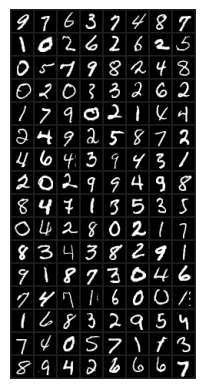

Rótulos:  9 7 6 3 7 4 8 7 1 0 2 6 2 6 2 5 0 5 7 9 8 2 4 8 0 2 0 3 3 2 6 2 1 7 9 0 2 1 4 4 2 4 9 2 5 8 7 2 4 6 4 3 9 4 3 1 2 0 2 9 9 4 9 8 8 4 7 1 3 5 3 5 0 4 2 8 0 2 1 7 8 3 4 3 8 2 9 1 9 1 8 7 3 0 4 6 7 4 7 1 6 0 0 1 1 6 8 3 2 9 5 4 7 4 0 5 7 1 1 3 8 9 4 2 6 6 6 7


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Função para exibir uma imagem
def imshow(img):
    # A normalização precisa ser revertida para a visualização correta
    # Média = 0.1307, Desvio Padrão = 0.3081
    img = img * 0.3081 + 0.1307 
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off') # Remove os eixos
    plt.show()

# Pega um lote (batch) de imagens de treino
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Mostra as imagens em uma grade
# O make_grid organiza o lote de imagens em uma única imagem-grade
imshow(torchvision.utils.make_grid(images))

# Imprime os rótulos correspondentes
print('Rótulos: ', ' '.join(f'{labels[j].item()}' for j in range(batch_size)))

## Funções de Custo (Loss Functions)

A função de custo $J(\theta)$ mede a discrepância entre a saída prevista pelo modelo $\hat{y}$ e o valor real $y$. O objetivo do treinamento é encontrar os parâmetros $\theta$ que minimizam $J(\theta)$.

### Funções Comuns

-   **Mean Squared Error (MSE)**: Utilizada principalmente para tarefas de regressão. Calcula a média dos erros quadráticos entre a previsão e o valor real.
    $$ J_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $$
-   **Binary Cross-Entropy (BCE)**: Utilizada para classificação binária. Geralmente é combinada com uma camada de saída Sigmoid.
    $$ J_{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right] $$
-   **Cross-Entropy Loss**: Utilizada para classificação multiclasse. No PyTorch, `nn.CrossEntropyLoss` combina `nn.LogSoftmax` e `nn.NLLLoss`, sendo numericamente mais estável. Ela espera como entrada os *logits* brutos do modelo e os rótulos de classe como inteiros.
    $$ J_{CE} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{C} y_{i,c} \log(\hat{p}_{i,c}) $$
    Onde $y_{i,c}$ é 1 se a amostra $i$ pertence à classe $c$ (0 caso contrário), e $\hat{p}_{i,c}$ é a probabilidade prevista pelo modelo para a amostra $i$ pertencer à classe $c$.

In [12]:
# Instanciando a função de custo para classificação multiclasse
loss_function = nn.CrossEntropyLoss()

# Exemplo de uso:
# Saída do modelo (logits) para um batch de 3 amostras e 10 classes
output_logits = torch.randn(3, 10)
# Rótulos verdadeiros
target_labels = torch.tensor([1, 4, 9]) # Classe 1, Classe 4, Classe 9

# Calculando a perda
loss = loss_function(output_logits, target_labels)
print(f"Valor da perda (loss): {loss.item()}")



Valor da perda (loss): 3.4403092861175537


## Otimizadores

O otimizador implementa o algoritmo de atualização dos parâmetros do modelo, $\theta$, com base nos gradientes da função de custo, $\nabla_{\theta} J(\theta)$. O objetivo é convergir para um mínimo (local ou global) da função de custo.

O algoritmo mais fundamental é o **Stochastic Gradient Descent (SGD)**. A regra de atualização para um parâmetro $\theta$ no passo de tempo $t$ é definida como:
$$
\theta_{t+1} = \theta_t - \eta \nabla_{\theta} J(\theta_t)
$$
onde $\eta$ é a taxa de aprendizado (*learning rate*), um hiperparâmetro que controla o tamanho do passo na direção do gradiente negativo.

Otimizadores mais avançados, como o **Adam (Adaptive Moment Estimation)**, utilizam taxas de aprendizado adaptativas para cada parâmetro, mantendo uma estimativa do primeiro momento (a média) e do segundo momento (a variância não centrada) dos gradientes, o que frequentemente leva a uma convergência mais rápida.

In [13]:
# Instanciando o modelo
learning_rate = 0.001
model = NeuralNetwork(input_size=784, hidden_size=128, num_classes=10)

# Instanciando o otimizador Adam
# Passamos os parâmetros do modelo que devem ser otimizados (model.parameters()) e a taxa de aprendizado.
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# O otimizador possui métodos cruciais:
# optimizer.zero_grad(): Zera os gradientes de todos os parâmetros antes de um novo cálculo de backward pass. Isto é necessário porque o método .backward() acumula os gradientes por padrão.

# optimizer.step(): Atualiza os parâmetros do modelo usando a lógica do otimizador (e.g., Adam) e os gradientes armazenados no atributo .grad de cada parâmetro.

## Treinamento: O Ciclo Completo

O treinamento de uma rede neural consiste em um loop que itera sobre o dataset por várias "épocas" (*epochs*). Uma época é uma passagem completa por todo o dataset de treinamento. Dentro de cada época, iteramos sobre os *batches* de dados.

Para cada *batch*, o ciclo de treinamento é:
1.  **Zerar os gradientes**: Chamar `optimizer.zero_grad()`.
2.  **Forward Pass**: Passar os dados de entrada pelo modelo para obter as previsões (logits).
3.  **Calcular a Perda**: Comparar as previsões com os rótulos verdadeiros usando a função de custo.
4.  **Backward Pass**: Chamar `loss.backward()` para calcular os gradientes da perda em relação a cada parâmetro do modelo.
5.  **Atualizar os Pesos**: Chamar `optimizer.step()` para que o otimizador atualize os pesos com base nos gradientes.

In [14]:
# Hiperparâmetros
num_epochs = 5
input_size = 784 # 28x28
hidden_size = 32
num_classes = 10
learning_rate = 0.001

In [15]:
# Instanciando o modelo, função de custo e otimizador e movendo o modelo para o dispositivo
model = NeuralNetwork(input_size, hidden_size, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [16]:
from tqdm import tqdm

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):

    # Treino
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(100 * correct / total)

    # Validação
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1} Val"):
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = outputs.argmax(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_losses.append(val_loss / len(test_loader))
    val_accuracies.append(100 * correct / total)

    print(
        f"Epoch {epoch+1} | "
        f"Train loss {train_losses[-1]:.4f}, acc {train_accuracies[-1]:.2f}% | "
        f"Val loss {val_losses[-1]:.4f}, acc {val_accuracies[-1]:.2f}%"
    )

Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 158.69it/s]


Epoch 1 | Train loss 0.4139, acc 88.55% | Val loss 0.2487, acc 92.68%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 172.19it/s]


Epoch 2 | Train loss 0.2171, acc 93.70% | Val loss 0.1837, acc 94.60%


Epoch 3 Val: 100%|██████████| 79/79 [00:00<00:00, 174.09it/s]


Epoch 3 | Train loss 0.1711, acc 95.04% | Val loss 0.1548, acc 95.50%


Epoch 4 Val: 100%|██████████| 79/79 [00:00<00:00, 171.07it/s]


Epoch 4 | Train loss 0.1443, acc 95.80% | Val loss 0.1377, acc 95.91%


Epoch 5 Val: 100%|██████████| 79/79 [00:00<00:00, 177.05it/s]

Epoch 5 | Train loss 0.1228, acc 96.36% | Val loss 0.1237, acc 96.26%


### Visualização das Curvas de Aprendizado

As curvas de aprendizado plotam as métricas de desempenho (como perda e acurácia) para os conjuntos de treinamento e validação ao longo das épocas. Elas são ferramentas de diagnóstico essenciais:

-   **Curva de Perda (Loss Curve)**: Mostra a evolução da função de custo. Idealmente, ambas as perdas (treino e validação) devem diminuir. Se a perda de validação começar a aumentar enquanto a de treino continua caindo, é um sinal claro de *overfitting*.
-   **Curva de Acurácia (Accuracy Curve)**: Mostra a evolução da acurácia. Idealmente, ambas devem aumentar e convergir. Uma grande diferença entre a acurácia de treino e a de validação também indica *overfitting*.

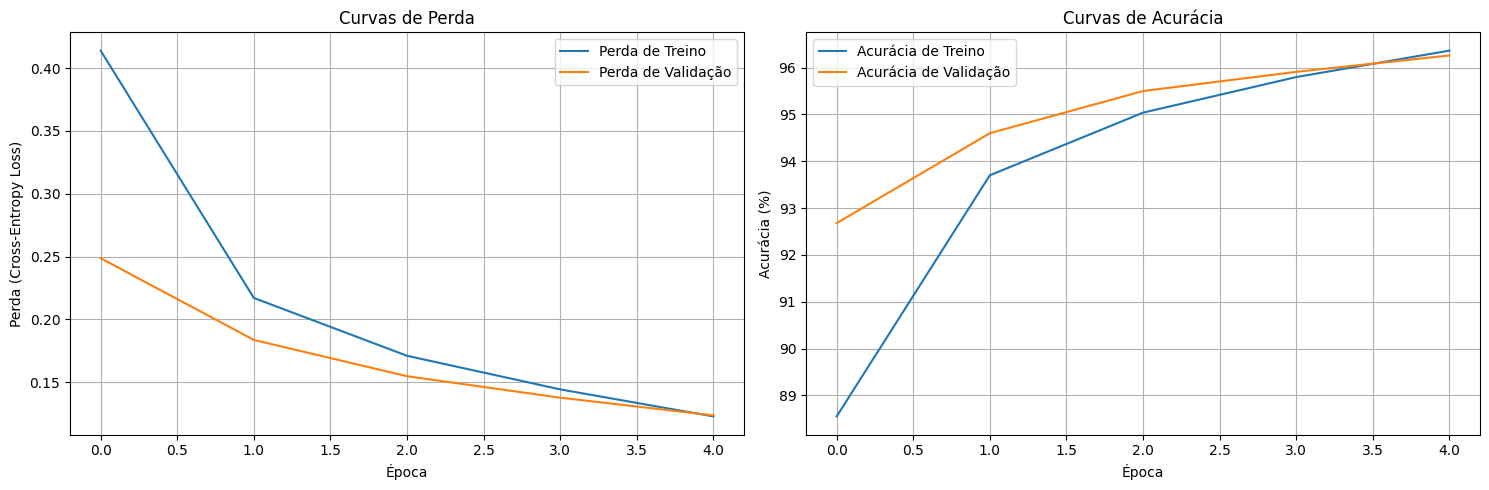

In [17]:
# Criando os plots
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plot da Curva de Perda
axs[0].plot(train_losses, label='Perda de Treino')
axs[0].plot(val_losses, label='Perda de Validação')
axs[0].set_title("Curvas de Perda")
axs[0].set_xlabel("Época")
axs[0].set_ylabel("Perda (Cross-Entropy Loss)")
axs[0].legend()
axs[0].grid(True)

# Plot da Curva de Acurácia
axs[1].plot(train_accuracies, label='Acurácia de Treino')
axs[1].plot(val_accuracies, label='Acurácia de Validação')
axs[1].set_title("Curvas de Acurácia")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Acurácia (%)")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

### Avaliação do Modelo

Após o treinamento, é fundamental avaliar a performance do modelo em dados que ele nunca viu, ou seja, o conjunto de teste. Durante a avaliação, não precisamos calcular gradientes, o que economiza memória e computação. Para isso, usamos o contexto `torch.no_grad()`.

In [18]:
# Colocando o modelo em modo de avaliação (desativa camadas como Dropout, se houver)
model.eval()

# O contexto torch.no_grad() desabilita o cálculo de gradientes
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # A classe com o maior logit é a previsão
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Acurácia do modelo no dataset de teste: {100 * correct / total:.2f} %')

Acurácia do modelo no dataset de teste: 96.26 %


## Exercícios

### Exercício 1: Arquitetura

Substitua o carregamento do dataset original pelo **Fashion MNIST**, disponível em `torchvision.datasets.FashionMNIST`, e execute o treinamento com a arquitetura de rede atual. Em seguida, modifique a classe `NeuralNetwork` para incluir uma **segunda camada oculta** e repita o experimento. Compare o desempenho das duas arquiteturas especificamente sobre o Fashion MNIST e analise se a maior profundidade da rede facilitou a classificação de itens de vestuário em comparação aos dígitos manuscritos.

#### Resolução do exercício 1:

##### Carregamento dos datasets

In [19]:
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

# Baixando o dataset de teste
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    transform=transform
)

##### Definindo os dataloaders

In [20]:
batch_size = 128
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)


##### Exibindo as imagens

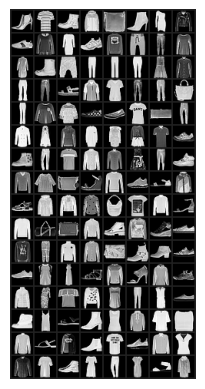

Rótulos:  9 0 9 4 8 9 3 4 7 6 3 5 2 1 1 2 6 9 1 1 1 1 3 6 1 1 5 4 0 1 1 8 1 2 6 7 5 0 8 1 4 6 2 3 4 3 0 7 9 1 0 6 6 3 1 7 2 3 8 5 2 7 5 4 5 4 4 6 8 0 4 5 2 8 8 4 9 2 5 7 2 1 4 6 8 9 9 7 7 0 3 5 2 5 4 7 4 3 6 2 0 1 3 7 9 3 5 9 0 2 6 0 6 5 2 9 0 7 4 0 6 3 9 3 1 3 5 4


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Função para exibir uma imagem
def imshow(img):
    # A normalização precisa ser revertida para a visualização correta
    # Média = 0.1307, Desvio Padrão = 0.3081
    img = img * 0.3081 + 0.1307 
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off') # Remove os eixos
    plt.show()

# Pega um lote (batch) de imagens de treino
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Mostra as imagens em uma grade
# O make_grid organiza o lote de imagens em uma única imagem-grade
imshow(torchvision.utils.make_grid(images))

# Imprime os rótulos correspondentes
print('Rótulos: ', ' '.join(f'{labels[j].item()}' for j in range(batch_size)))

##### Treinando o modelo

In [22]:
print(f"num_epochs: {num_epochs}")
num_epochs = 10
print(f"num_epochs: {num_epochs}")

num_epochs: 5
num_epochs: 10


In [23]:
from tqdm import tqdm

def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):

        # Treino
        model.train()
        train_loss, correct, total = 0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = outputs.argmax(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(100 * correct / total)

        # Validação
        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1} Val"):
                images = images.view(images.size(0), -1).to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = outputs.argmax(1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_losses.append(val_loss / len(test_loader))
        val_accuracies.append(100 * correct / total)

        print(
            f"Epoch {epoch+1} | "
            f"Train loss {train_losses[-1]:.4f}, acc {train_accuracies[-1]:.2f}% | "
            f"Val loss {val_losses[-1]:.4f}, acc {val_accuracies[-1]:.2f}%"
        )
    return train_losses, val_losses, train_accuracies, val_accuracies

train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs)

Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 168.79it/s]


Epoch 1 | Train loss 0.6224, acc 79.29% | Val loss 0.4640, acc 83.49%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 174.48it/s]


Epoch 2 | Train loss 0.4190, acc 84.97% | Val loss 0.4244, acc 84.92%


Epoch 3 Val: 100%|██████████| 79/79 [00:00<00:00, 177.26it/s]


...

Epoch 8 | Train loss 0.3125, acc 88.53% | Val loss 0.3703, acc 86.31%


Epoch 9 Val: 100%|██████████| 79/79 [00:00<00:00, 166.90it/s]


Epoch 9 | Train loss 0.3046, acc 88.77% | Val loss 0.3696, acc 86.56%


Epoch 10 Val: 100%|██████████| 79/79 [00:00<00:00, 166.03it/s]

Epoch 10 | Train loss 0.2963, acc 89.16% | Val loss 0.3667, acc 86.52%


##### Visualizando resultados

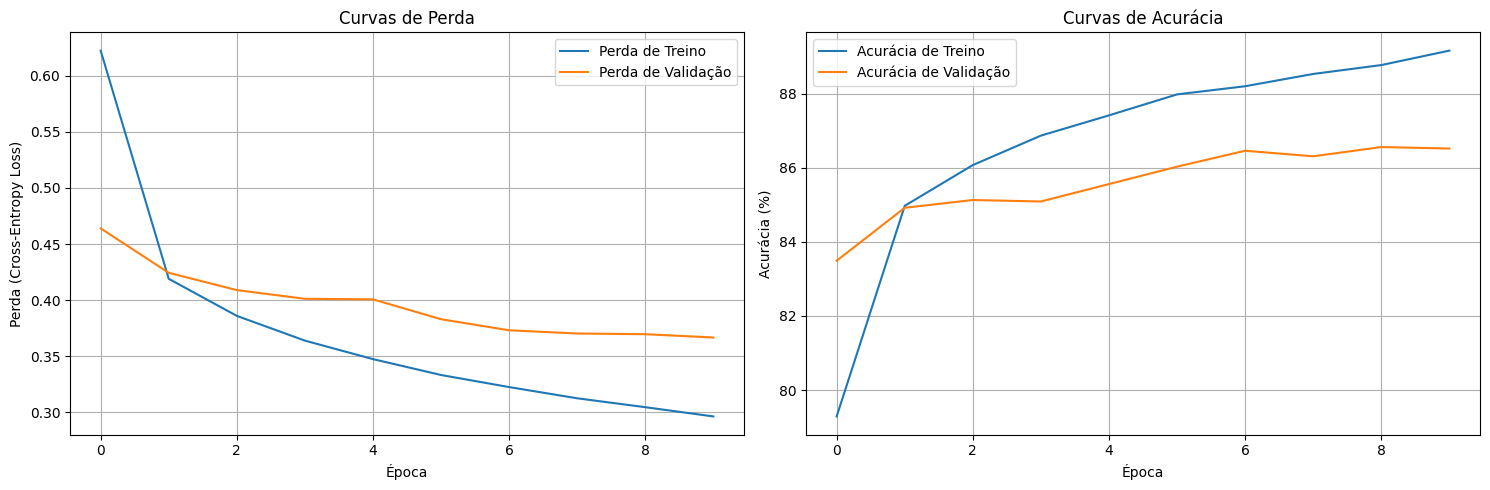

In [24]:
def plot_results(train_losses, val_losses, train_accuracies, val_accuracies, title = ""):
  # Criando os plots
  fig, axs = plt.subplots(1, 2, figsize=(15, 5))

  # Plot da Curva de Perda
  axs[0].plot(train_losses, label='Perda de Treino')
  axs[0].plot(val_losses, label='Perda de Validação')
  axs[0].set_title(f"Curvas de Perda{title}")
  axs[0].set_xlabel("Época")
  axs[0].set_ylabel("Perda (Cross-Entropy Loss)")
  axs[0].legend()
  axs[0].grid(True)

  # Plot da Curva de Acurácia
  axs[1].plot(train_accuracies, label='Acurácia de Treino')
  axs[1].plot(val_accuracies, label='Acurácia de Validação')
  axs[1].set_title(f"Curvas de Acurácia{title}")
  axs[1].set_xlabel("Época")
  axs[1].set_ylabel("Acurácia (%)")
  axs[1].legend()
  axs[1].grid(True)

  plt.tight_layout()
  plt.show()

plot_results(train_losses, val_losses, train_accuracies, val_accuracies)

##### Definindo nova arquitetura de rede neural

In [25]:
# Definindo o mesmo modelo anterior, mas agora com um layer adicional (layer3)
class NeuralNetwork2(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.relu1(out)
        out = self.layer2(out)
        out = self.relu2(out)
        out = self.layer3(out)
        return out

# Instanciando o modelo
model_class = NeuralNetwork2(input_size=784, hidden_size=128, num_classes=10)

# O uso é idêntico
logits_class = model_class(input_images)

print(f"Formato da saída do modelo (classe): {logits_class.shape}")
print(f"\nEstrutura do modelo:\n{model_class}")

Formato da saída do modelo (classe): torch.Size([64, 10])

Estrutura do modelo:
NeuralNetwork2(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=128, out_features=10, bias=True)
)


##### Aplicando o novo modelo

In [26]:
print(f"num_epochs: {num_epochs}")
num_epochs = 10
print(f"num_epochs: {num_epochs}")

num_epochs: 10
num_epochs: 10


In [27]:
model2 = NeuralNetwork2(input_size, hidden_size, num_classes).to(device)
criterion2 = nn.CrossEntropyLoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=learning_rate)

train_losses2, val_losses2, train_accuracies2, val_accuracies2 = train_model(model2, train_loader, test_loader, criterion2, optimizer2, num_epochs)

Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 149.83it/s]


Epoch 1 | Train loss 0.5892, acc 79.00% | Val loss 0.4384, acc 84.16%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 161.36it/s]


Epoch 2 | Train loss 0.3932, acc 85.83% | Val loss 0.3931, acc 85.53%


Epoch 3 Val: 100%|██████████| 79/79 [00:00<00:00, 147.58it/s]


...

Epoch 8 | Train loss 0.2882, acc 89.36% | Val loss 0.3441, acc 87.51%


Epoch 9 Val: 100%|██████████| 79/79 [00:00<00:00, 143.41it/s]


Epoch 9 | Train loss 0.2817, acc 89.52% | Val loss 0.3602, acc 86.98%


Epoch 10 Val: 100%|██████████| 79/79 [00:00<00:00, 154.52it/s]

Epoch 10 | Train loss 0.2757, acc 89.72% | Val loss 0.3501, acc 87.25%


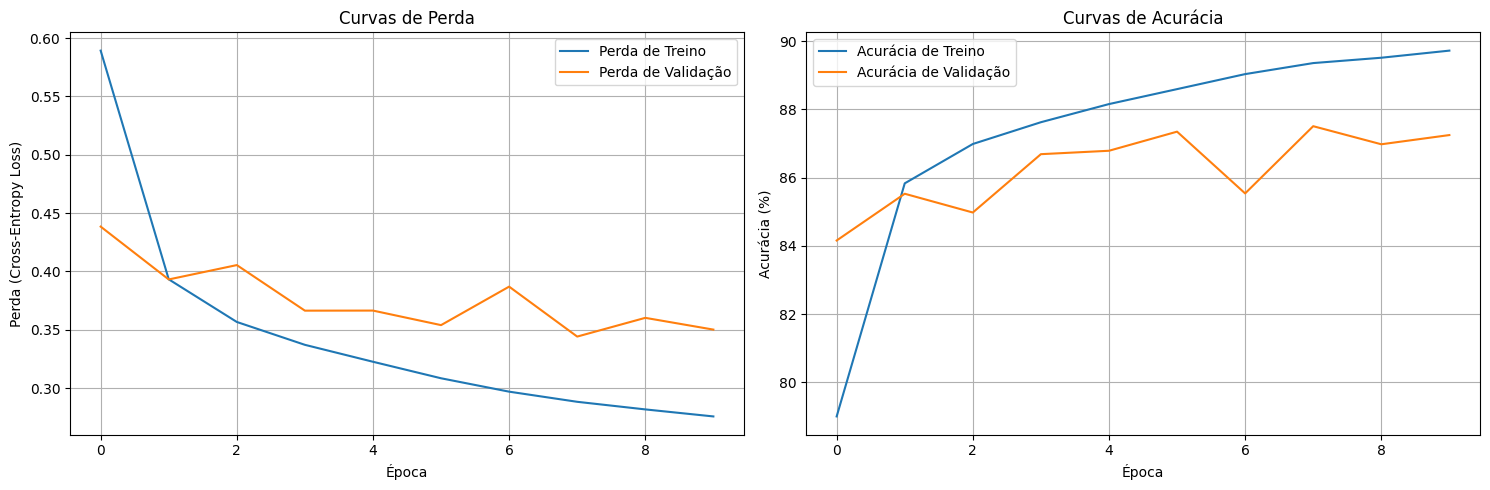

In [28]:

plot_results(train_losses2, val_losses2, train_accuracies2, val_accuracies2)

### Exercício 2: Otimização por Grid Search

Implemente uma rotina de treinamento para testar sistematicamente combinações fixas de hiperparâmetros e encontrar a melhor configuração para o modelo. Você deve testar todas as combinações possíveis entre os seguintes valores:
* **Taxa de Aprendizado (Learning Rate):** `[0.1, 0.01, 0.001]`
* **Neurônios Ocultos (Hidden Size):** `[128, 256, 512]`

Reinicie o modelo para cada combinação, execute o treino por 2 épocas e identifique qual par de valores entregou a maior acurácia no conjunto de validação.

#### Resolução Exercício 2:



In [29]:
print(f"num_epochs: {num_epochs}")
num_epochs = 2
print(f"num_epochs: {num_epochs}")

num_epochs: 10
num_epochs: 2


Executando grid search...
Total de combinações a testar: 12
Testando configuração 1/12: {'hidden_layer_sizes': 128, 'learning_rate_init': 0.0001}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 158.70it/s]


Epoch 1 | Train loss 0.8417, acc 73.58% | Val loss 0.5291, acc 81.18%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 160.44it/s]


Epoch 2 | Train loss 0.4752, acc 83.20% | Val loss 0.4696, acc 83.23%


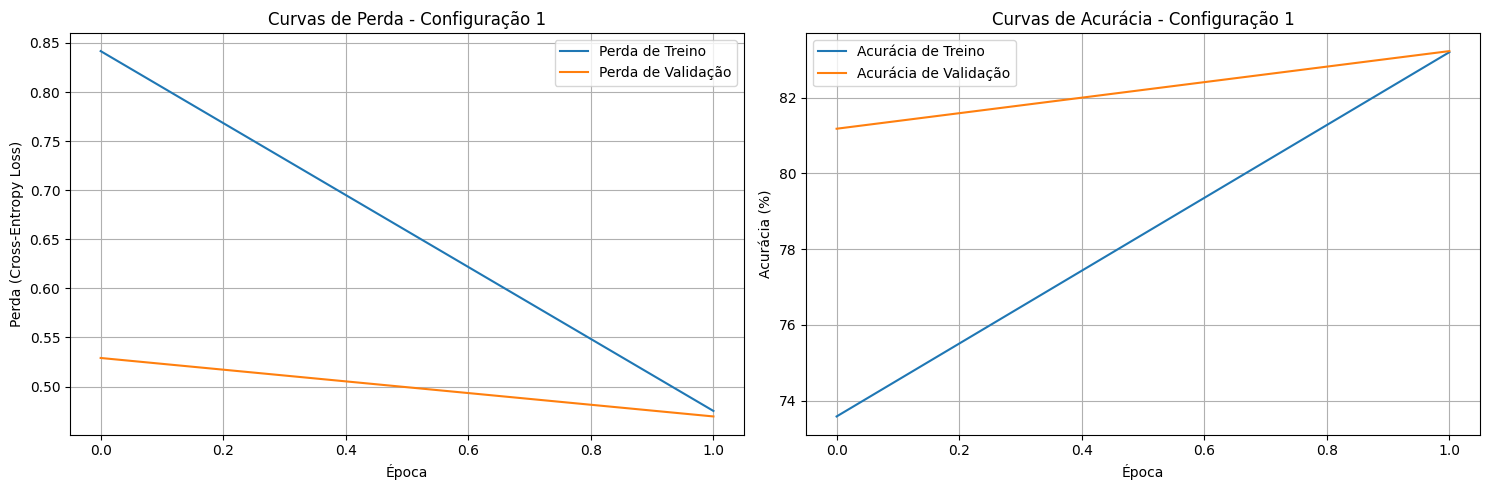

Testando configuração 2/12: {'hidden_layer_sizes': 128, 'learning_rate_init': 0.001}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 167.93it/s]


Epoch 1 | Train loss 0.5012, acc 82.07% | Val loss 0.4235, acc 84.63%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 163.04it/s]


Epoch 2 | Train loss 0.3586, acc 86.85% | Val loss 0.3753, acc 86.43%


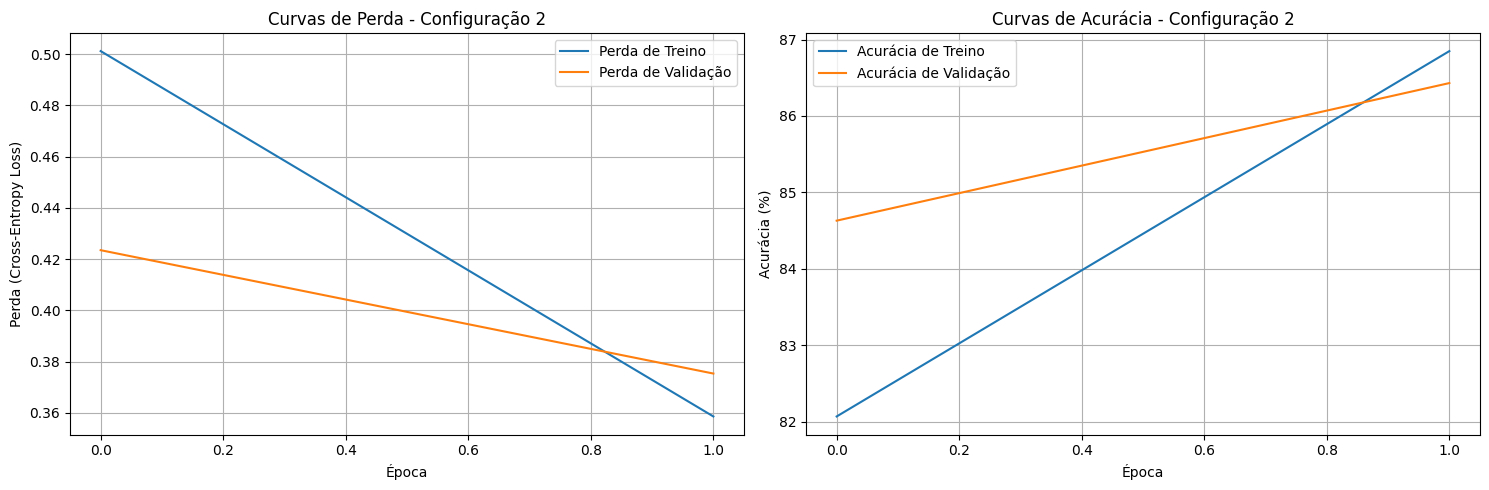

Testando configuração 3/12: {'hidden_layer_sizes': 128, 'learning_rate_init': 0.01}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 166.16it/s]


Epoch 1 | Train loss 0.4998, acc 81.97% | Val loss 0.4231, acc 84.63%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 167.12it/s]


Epoch 2 | Train loss 0.3972, acc 85.86% | Val loss 0.4123, acc 85.19%


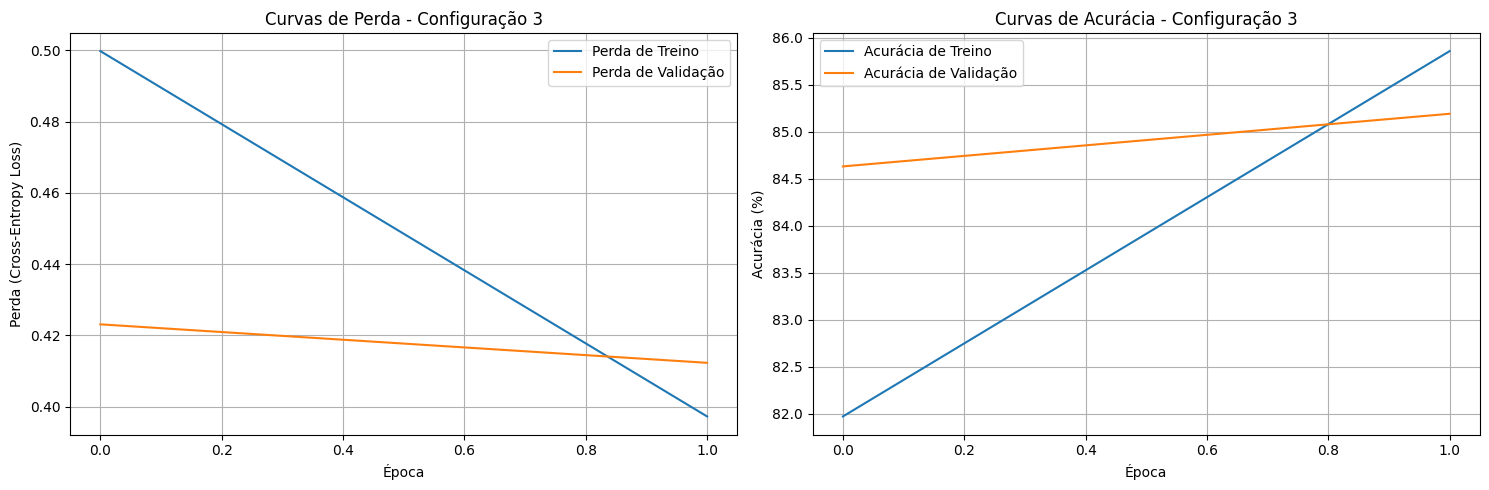

Testando configuração 4/12: {'hidden_layer_sizes': 128, 'learning_rate_init': 0.1}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 165.24it/s]


Epoch 1 | Train loss 3.8209, acc 31.11% | Val loss 2.6496, acc 23.19%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 166.44it/s]


Epoch 2 | Train loss 2.4027, acc 13.07% | Val loss 2.3174, acc 10.03%


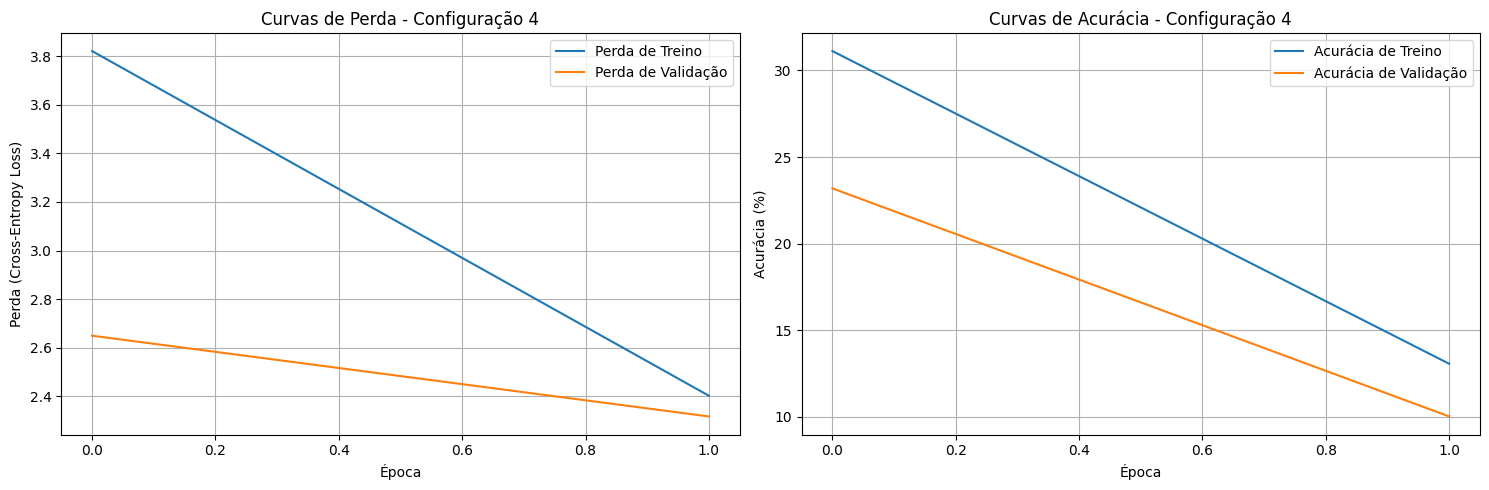

Testando configuração 5/12: {'hidden_layer_sizes': 256, 'learning_rate_init': 0.0001}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 162.79it/s]


Epoch 1 | Train loss 0.7125, acc 77.19% | Val loss 0.4847, acc 82.52%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 153.31it/s]


Epoch 2 | Train loss 0.4337, acc 84.65% | Val loss 0.4454, acc 84.16%


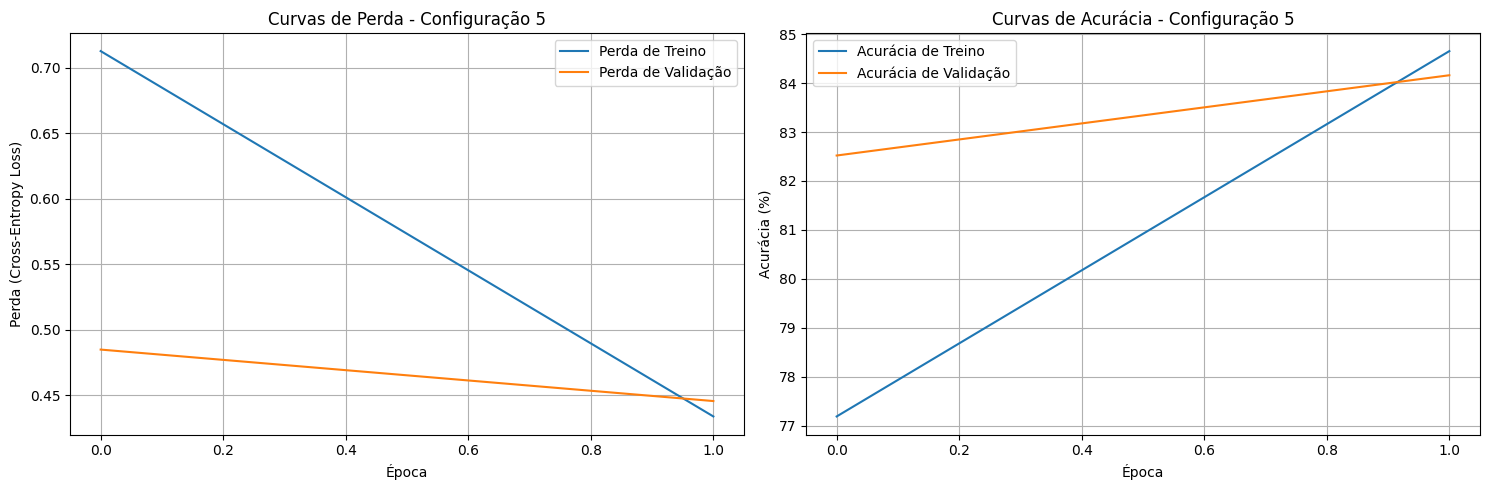

Testando configuração 6/12: {'hidden_layer_sizes': 256, 'learning_rate_init': 0.001}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 154.82it/s]


Epoch 1 | Train loss 0.4745, acc 82.87% | Val loss 0.3990, acc 85.53%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 156.54it/s]


Epoch 2 | Train loss 0.3427, acc 87.38% | Val loss 0.3529, acc 87.15%


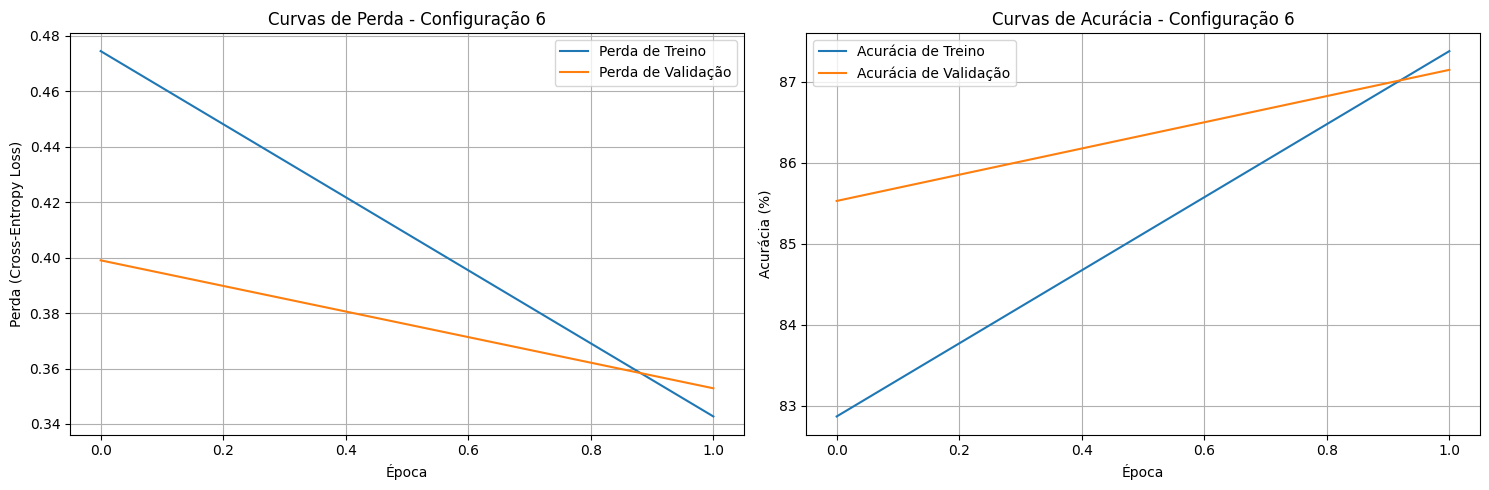

Testando configuração 7/12: {'hidden_layer_sizes': 256, 'learning_rate_init': 0.01}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 157.43it/s]


Epoch 1 | Train loss 0.5353, acc 81.60% | Val loss 0.4668, acc 83.41%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 157.38it/s]


Epoch 2 | Train loss 0.4052, acc 85.61% | Val loss 0.4307, acc 84.11%


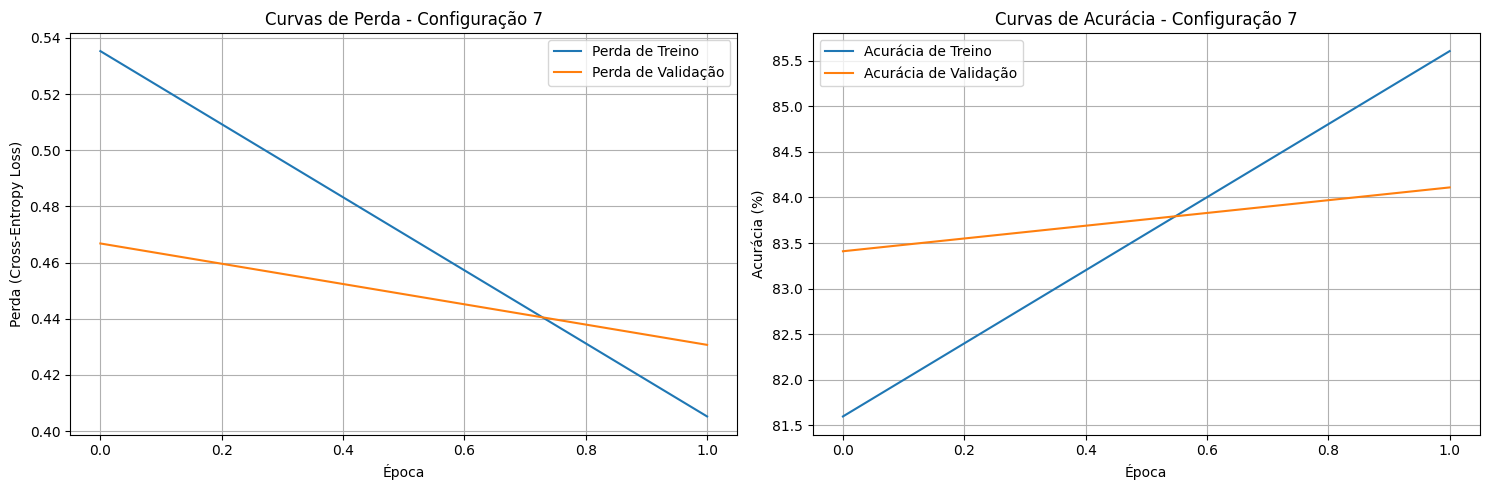

Testando configuração 8/12: {'hidden_layer_sizes': 256, 'learning_rate_init': 0.1}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 159.02it/s]


Epoch 1 | Train loss 9.2406, acc 18.54% | Val loss 3.7210, acc 11.52%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 155.62it/s]


Epoch 2 | Train loss 3.4695, acc 12.83% | Val loss 2.2612, acc 11.78%


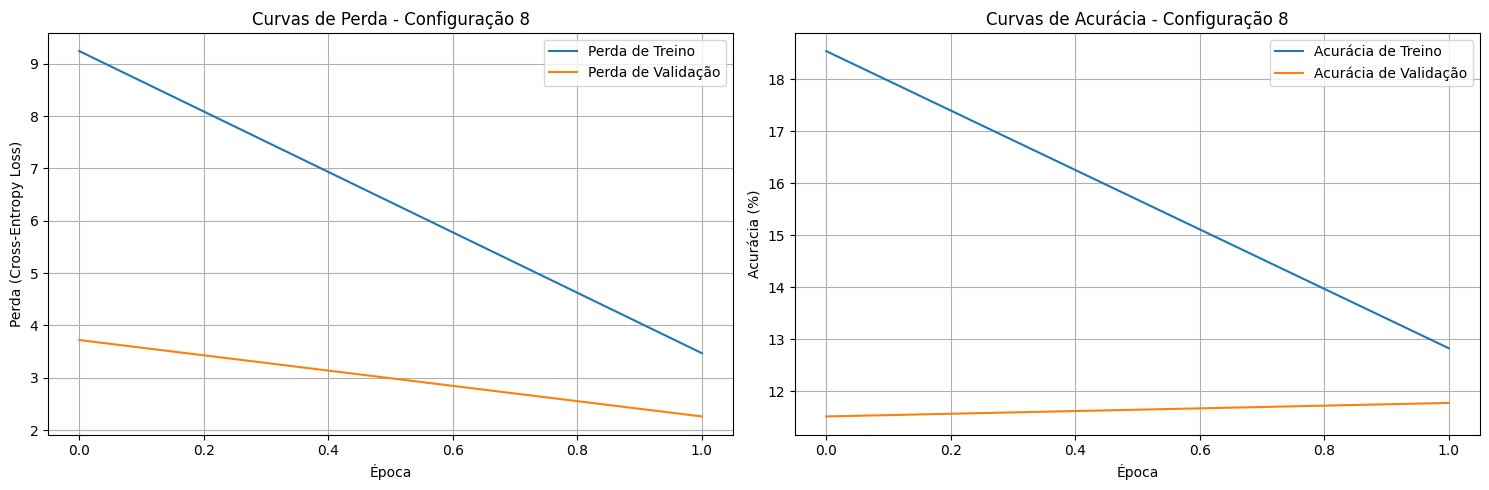

Testando configuração 9/12: {'hidden_layer_sizes': 512, 'learning_rate_init': 0.0001}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 142.34it/s]


Epoch 1 | Train loss 0.6192, acc 79.58% | Val loss 0.4515, acc 83.71%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 155.11it/s]


Epoch 2 | Train loss 0.4018, acc 85.67% | Val loss 0.4203, acc 84.79%


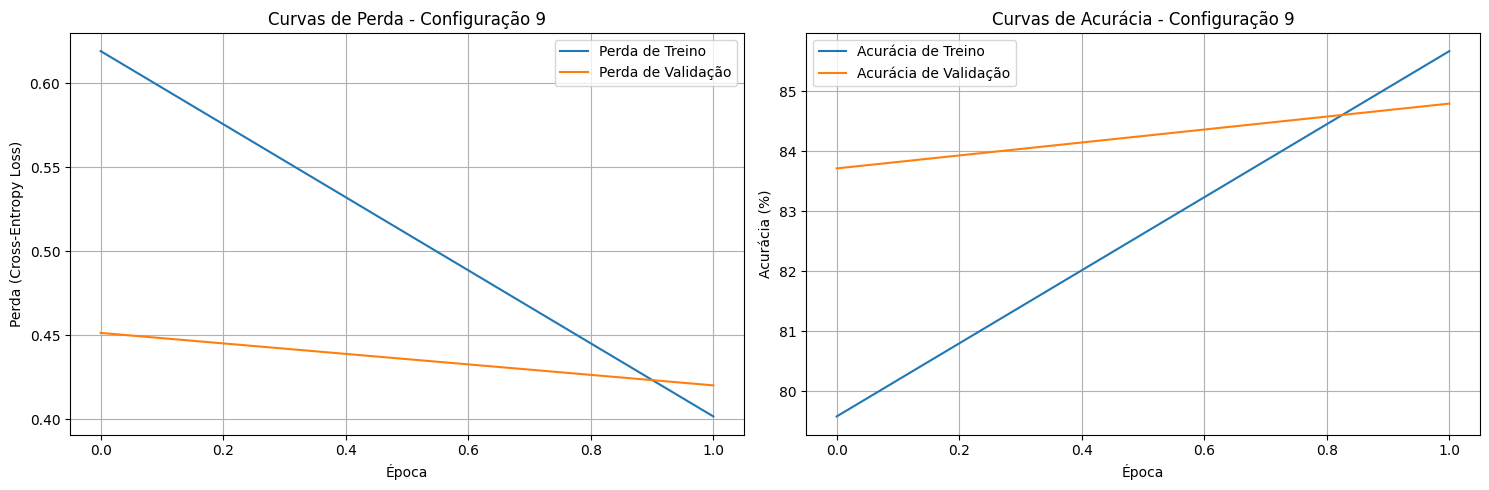

Testando configuração 10/12: {'hidden_layer_sizes': 512, 'learning_rate_init': 0.001}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 156.17it/s]


Epoch 1 | Train loss 0.4545, acc 83.44% | Val loss 0.4006, acc 85.15%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 151.63it/s]


Epoch 2 | Train loss 0.3361, acc 87.56% | Val loss 0.3469, acc 87.08%


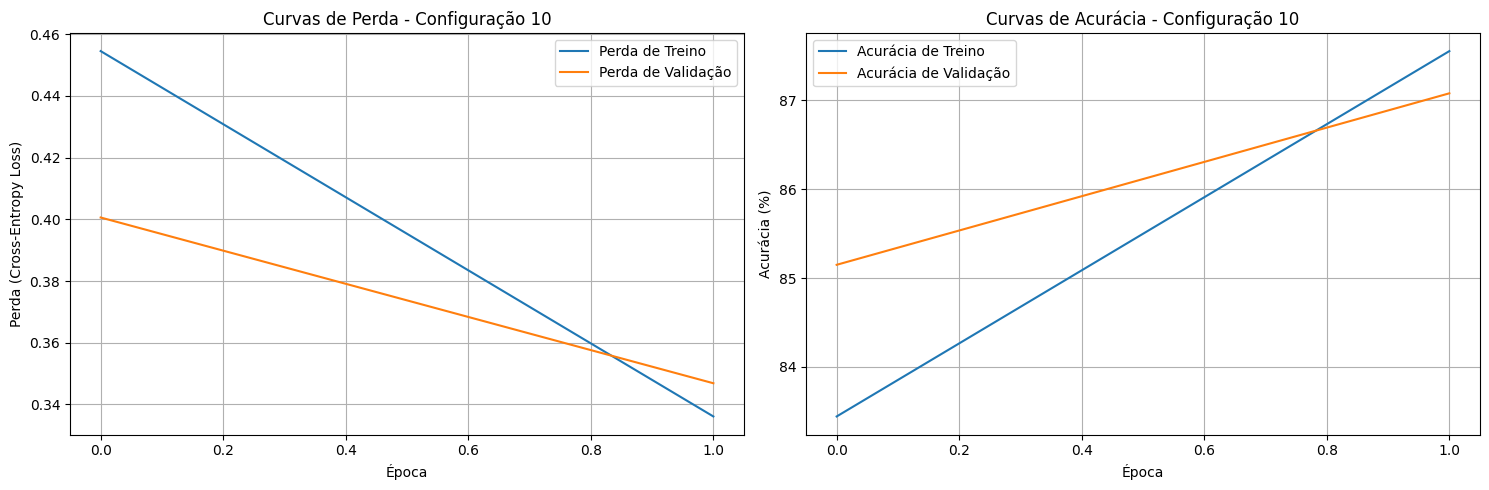

Testando configuração 11/12: {'hidden_layer_sizes': 512, 'learning_rate_init': 0.01}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 154.91it/s]


Epoch 1 | Train loss 0.6012, acc 80.66% | Val loss 0.4431, acc 83.97%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 155.14it/s]


Epoch 2 | Train loss 0.4176, acc 84.99% | Val loss 0.4261, acc 84.82%


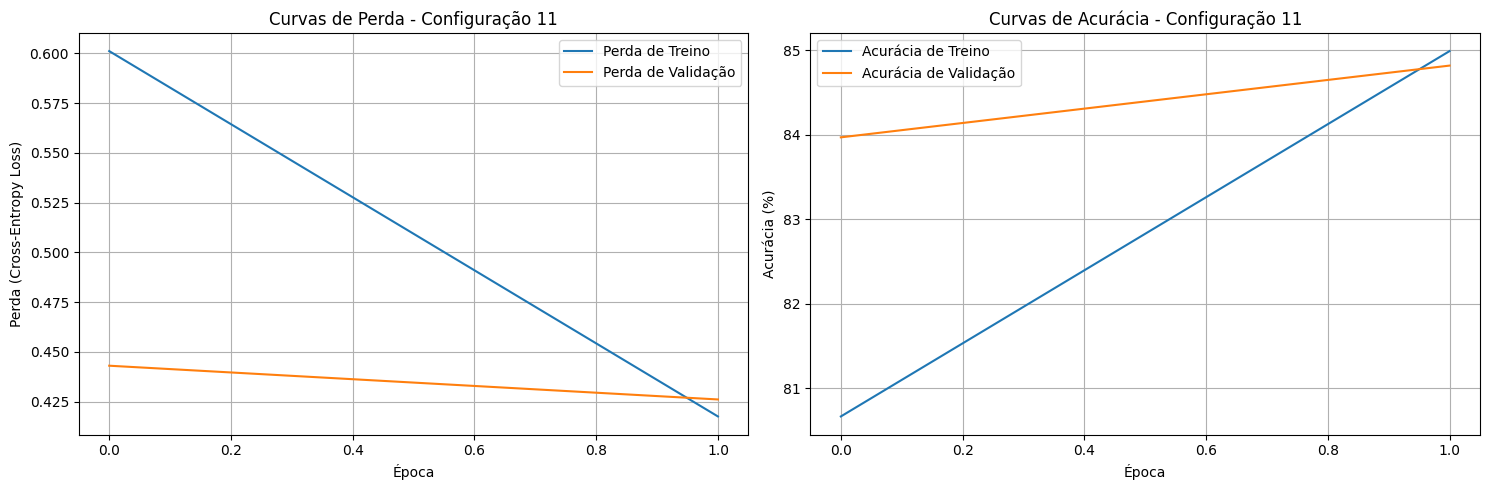

Testando configuração 12/12: {'hidden_layer_sizes': 512, 'learning_rate_init': 0.1}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 143.19it/s]


Epoch 1 | Train loss 35.3446, acc 18.33% | Val loss 20.1531, acc 23.04%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 157.60it/s]


Epoch 2 | Train loss 14.4032, acc 14.97% | Val loss 16.3184, acc 13.38%


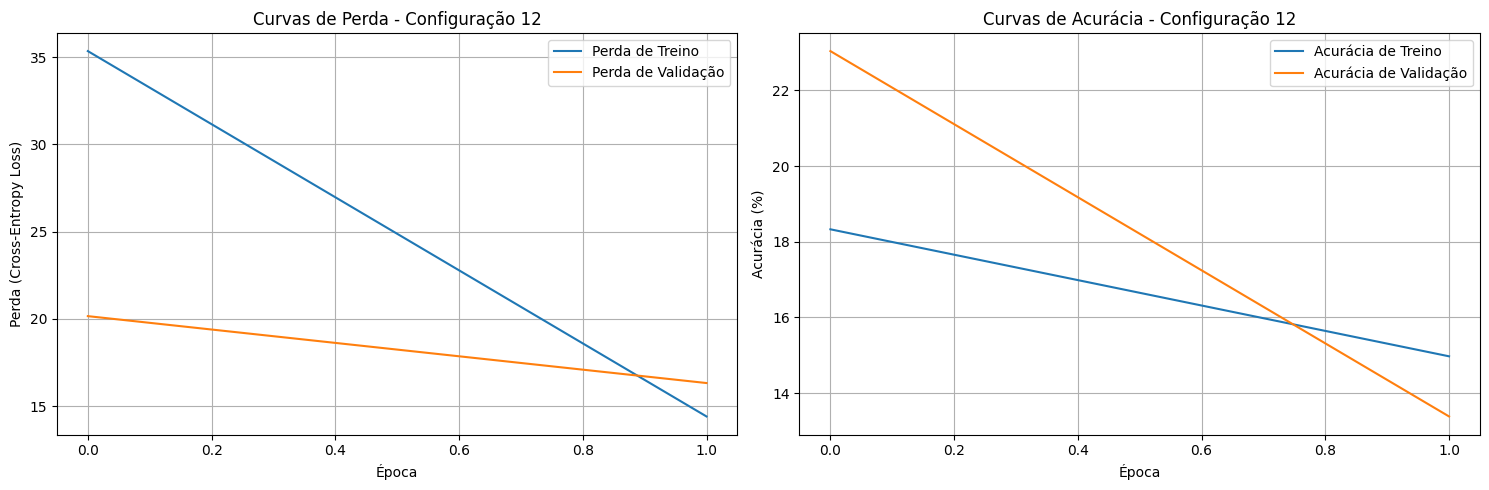

In [30]:
# Grid search para encontrar top 10 configurações
from sklearn.model_selection import ParameterGrid

param_grid = {
    'hidden_layer_sizes': [(128), (256), (512)],
    'learning_rate_init': [0.0001, 0.001, 0.01, 0.1]
}

results_holdout = []
print("Executando grid search...")

# Gerando todas as combinações de parâmetros
param_combinations = list(ParameterGrid(param_grid))
print(f"Total de combinações a testar: {len(param_combinations)}")

for i, params in enumerate(param_combinations):
    print(f"Testando configuração {i+1}/{len(param_combinations)}: {params}")
    
    model3 = NeuralNetwork2(input_size, params['hidden_layer_sizes'], num_classes).to(device)
    criterion3 = nn.CrossEntropyLoss()
    optimizer3 = torch.optim.Adam(model3.parameters(), lr=params['learning_rate_init'])

    train_losses3, val_losses3, train_accuracies3, val_accuracies3 = train_model(model3, train_loader, test_loader, criterion3, optimizer3, num_epochs)
    results_holdout.append({
        'params': params,
        'train_losses': train_losses3,
        'val_losses': val_losses3,
        'train_accuracies': train_accuracies3,
        'val_accuracies': val_accuracies3
    })
    plot_results(train_losses3, val_losses3, train_accuracies3, val_accuracies3, f" - Configuração {i+1}")

##### Resultados de Acuracia no conjunto de validacao

                                               params  \
0   {'hidden_layer_sizes': 128, 'learning_rate_ini...   
1   {'hidden_layer_sizes': 128, 'learning_rate_ini...   
2   {'hidden_layer_sizes': 128, 'learning_rate_ini...   
3   {'hidden_layer_sizes': 128, 'learning_rate_ini...   
4   {'hidden_layer_sizes': 256, 'learning_rate_ini...   
5   {'hidden_layer_sizes': 256, 'learning_rate_ini...   
6   {'hidden_layer_sizes': 256, 'learning_rate_ini...   
7   {'hidden_layer_sizes': 256, 'learning_rate_ini...   
8   {'hidden_layer_sizes': 512, 'learning_rate_ini...   
9   {'hidden_layer_sizes': 512, 'learning_rate_ini...   
10  {'hidden_layer_sizes': 512, 'learning_rate_ini...   
11  {'hidden_layer_sizes': 512, 'learning_rate_ini...   

                                  train_losses  \
0     [0.8416972652172992, 0.4751623223331183]   
1     [0.5012312917503466, 0.3585854607668004]   
2     [0.4997955788490869, 0.3972121039941621]   
3      [3.8208583573034325, 2.402657829622216]   
4     [0

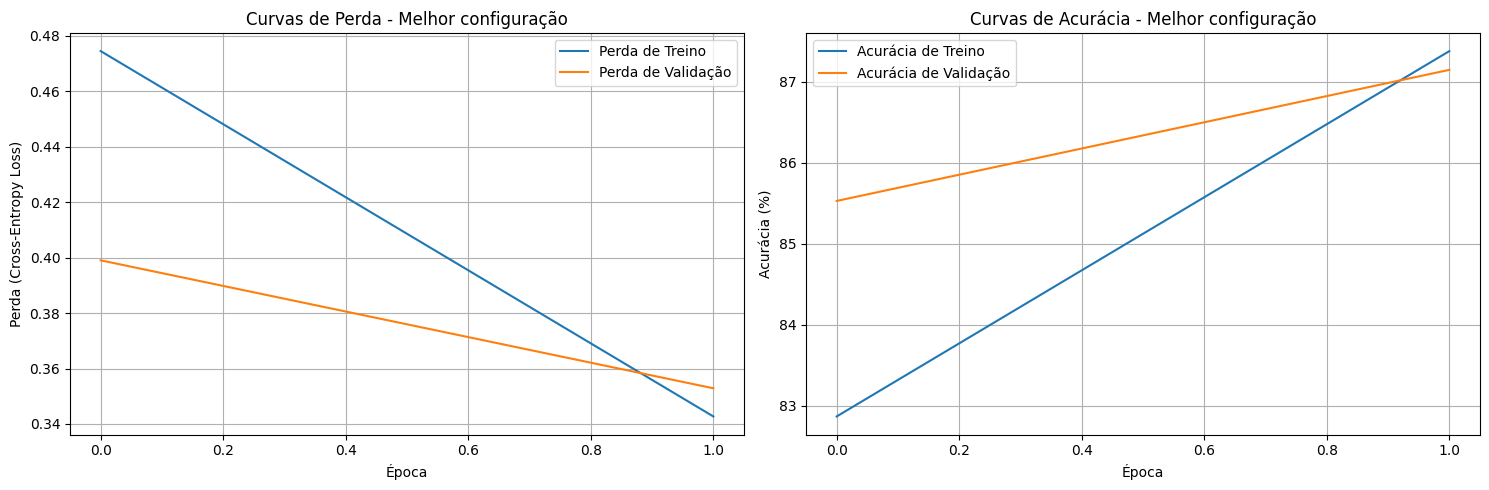

In [31]:
import pandas as pd

results_df = pd.DataFrame(results_holdout)

print(results_df)

results_df['best_val_accuracy'] = results_df['val_accuracies'].apply(max)
results_df['final_val_accuracy'] = results_df['val_accuracies'].apply(lambda x: x[-1])
results_df['best_val_loss'] = results_df['val_losses'].apply(min)
results_df['final_val_loss'] = results_df['val_losses'].apply(lambda x: x[-1])

results_df = results_df.sort_values(
    ['best_val_accuracy', 'best_val_loss'],
    ascending=[False, True]
)

best_result = results_df.iloc[0]

print("\nMelhor configuração:")
print(f"Parâmetros: {best_result['params']}")
print(f"Acurácia final de validação: {best_result['final_val_accuracy']}")
print(f"Acurácia máxima de validação: {best_result['best_val_accuracy']}")
print(f"Perda final de validação: {best_result['final_val_loss']}")
print(f"Perda mínima de validação: {best_result['best_val_loss']}")

plot_results(
    best_result['train_losses'],
    best_result['val_losses'],
    best_result['train_accuracies'],
    best_result['val_accuracies'],
    " - Melhor configuração"
)

### Exercício 3: Otimização por Random Search

Realize uma exploração estocástica do espaço de busca para identificar configurações otimizadas de forma mais eficiente. Execute 10 iterações de treinamento, onde, em cada tentativa, o código deve escolher valores aleatórios dentro dos seguintes intervalos:

* **Taxa de Aprendizado (Learning Rate):** Um valor aleatório entre `0.0001` e `0.1` (em escala logarítmica).
* **Neurônios Ocultos (Hidden Size):** Um número inteiro aleatório entre `64` e `512`.

Compare o melhor resultado obtido nesta busca aleatória com o melhor resultado do Grid Search anterior e avalie qual método pareceu mais promissor para encontrar um bom modelo rapidamente.

##### Resolução Exercício 3

In [32]:
import math
import random

num_random_trials = 10
random_results = []

print("Executando random search...")

for i in range(num_random_trials):
    # learning rate em escala logarítmica entre 1e-4 e 1e-1
    log_lr = random.uniform(math.log10(0.0001), math.log10(0.1))
    learning_rate = 10 ** log_lr

    # hidden size inteiro entre 64 e 512
    hidden_size = random.randint(64, 512)

    params = {
        'hidden_layer_sizes': hidden_size,
        'learning_rate_init': learning_rate
    }

    print(f"Teste aleatório {i+1}/{num_random_trials}: {params}")

    model_rand = NeuralNetwork2(input_size, hidden_size, num_classes).to(device)
    criterion_rand = nn.CrossEntropyLoss()
    optimizer_rand = torch.optim.Adam(model_rand.parameters(), lr=params['learning_rate_init'])

    train_losses, val_losses, train_accuracies, val_accuracies = train_model(
        model_rand,
        train_loader,
        test_loader,
        criterion_rand,
        optimizer_rand,
        num_epochs
    )

    random_results.append({
        'params': params,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'best_val_accuracy': max(val_accuracies),
        'final_val_accuracy': val_accuracies[-1],
        'best_val_loss': min(val_losses),
        'final_val_loss': val_losses[-1]
    })

Executando random search...
Teste aleatório 1/10: {'hidden_layer_sizes': 441, 'learning_rate_init': 0.07629740781581254}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 157.87it/s]


Epoch 1 | Train loss 12.4222, acc 45.98% | Val loss 2.0649, acc 44.28%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 160.67it/s]


Epoch 2 | Train loss 1.7984, acc 38.91% | Val loss 1.9154, acc 27.10%
Teste aleatório 2/10: {'hidden_layer_sizes': 344, 'learning_rate_init': 0.002040746423700573}


...

Epoch 2 | Train loss 0.4075, acc 85.39% | Val loss 0.4109, acc 85.15%
Teste aleatório 10/10: {'hidden_layer_sizes': 245, 'learning_rate_init': 0.016061023622065542}


Epoch 1 Val: 100%|██████████| 79/79 [00:00<00:00, 145.44it/s]


Epoch 1 | Train loss 0.6048, acc 79.66% | Val loss 0.5068, acc 82.65%


Epoch 2 Val: 100%|██████████| 79/79 [00:00<00:00, 161.54it/s]

Epoch 2 | Train loss 0.4544, acc 84.19% | Val loss 0.4726, acc 83.07%


                                              params  \
5  {'hidden_layer_sizes': 455, 'learning_rate_ini...   
3  {'hidden_layer_sizes': 263, 'learning_rate_ini...   
1  {'hidden_layer_sizes': 344, 'learning_rate_ini...   
8  {'hidden_layer_sizes': 396, 'learning_rate_ini...   
9  {'hidden_layer_sizes': 245, 'learning_rate_ini...   
6  {'hidden_layer_sizes': 376, 'learning_rate_ini...   
4  {'hidden_layer_sizes': 446, 'learning_rate_ini...   
0  {'hidden_layer_sizes': 441, 'learning_rate_ini...   
7  {'hidden_layer_sizes': 337, 'learning_rate_ini...   
2  {'hidden_layer_sizes': 477, 'learning_rate_ini...   

                                 train_losses  \
5  [0.45511515873835795, 0.33714966873116076]   
3    [0.5534162272268267, 0.3747457088882735]   
1   [0.45595442403608294, 0.3427921829383765]   
8   [0.6396095221484902, 0.40754996777089164]   
9     [0.604784210226429, 0.4543603227209689]   
6    [3.0507795637858703, 1.0193903066202012]   
4    [1.8886906102395007, 0.736777832894

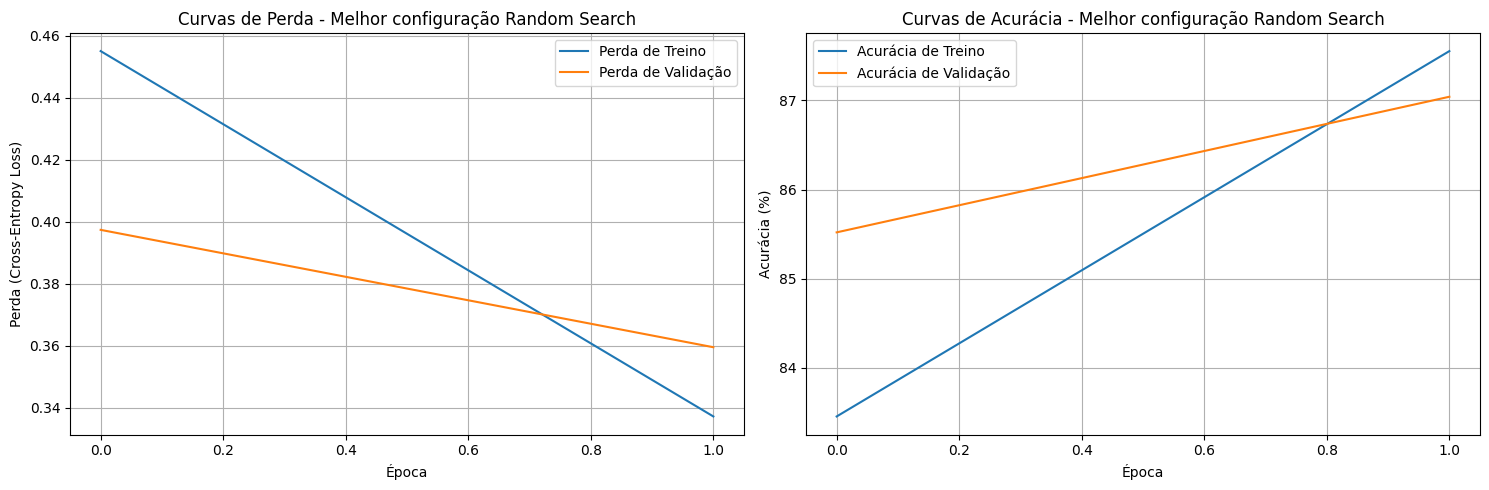

In [33]:
random_df = pd.DataFrame(random_results)

random_df = random_df.sort_values(
    ['best_val_accuracy', 'best_val_loss'],
    ascending=[False, True]
)

print(random_df)

best_random = random_df.iloc[0]

print("Melhor configuração da Random Search:")
print(best_random['params'])
print(f"Best val accuracy: {best_random['best_val_accuracy']:.2f}%")
print(f"Best val loss: {best_random['best_val_loss']:.4f}")

plot_results(
    best_random['train_losses'],
    best_random['val_losses'],
    best_random['train_accuracies'],
    best_random['val_accuracies'],
    " - Melhor configuração Random Search"
)

##### Comparacao Grid vs Random Search

In [34]:
best_grid = results_df.iloc[0]

print("\n===== COMPARAÇÃO FINAL =====")
print("Melhor do Grid Search:")
print(best_grid['params'])
print(f"Best val accuracy: {best_grid['best_val_accuracy']:.2f}%")
print(f"Best val loss: {best_grid['best_val_loss']:.4f}")

print("\nMelhor da Random Search:")
print(best_random['params'])
print(f"Best val accuracy: {best_random['best_val_accuracy']:.2f}%")
print(f"Best val loss: {best_random['best_val_loss']:.4f}")


===== COMPARAÇÃO FINAL =====
Melhor do Grid Search:
{'hidden_layer_sizes': 256, 'learning_rate_init': 0.001}
Best val accuracy: 87.15%
Best val loss: 0.3529

Melhor da Random Search:
{'hidden_layer_sizes': 455, 'learning_rate_init': 0.0014157207907760153}
Best val accuracy: 87.04%
Best val loss: 0.3595


Ambos modelos de busca chegaram em bons resultados, com o Grid Search encontrando um conjunto de parametros ligeiramente melhor nessa ultima execução. Entretanto, executei o random search algumas vezes e em algumas delas ele encontrou um resultado ligeiramente melhor. Mas em linhas gerais ambos foram relativamente parecidos.

Como nosso espaço de busca é relativamente pequeno, o Grid é mais sistemático em buscar regiões boas. Mas a vantagem do Random é que ele costuma explorar regiões do espaço mais variadas. Quando temos um parametro continuo como Learning Rate, o Grid exige um certo conhecimento do contexto para escolher valores adequados. Talvez um Random Search para começar a exploração, e depois um Grid Search com aquelas combinações mais promissoras pudesse ser uma abordagem interessante nesse caso.